## This is the code for generating the Influence Score vs. Loss Plot.

By default, if you play this file directly, it will generate the IF and TracIn score vs Samples Loss plot with respect to our experiment result.

**Main Guideline**:  
Read in the Influence lists and Loss lists -> Merge the two lists to have both influence score and loss for each sample -> Plot the influence score vs the Sample Loss -> Add a regression Line inside the plot

**Format**:  
**Input** The Influence lists and loss lists that you read in.  
**Output**  The influence score vs Loss Plot with regression line inserted.

You don't need to change anything else if you only want to produce the Influence Score vs Sample Loss plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

Import Area

In [35]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

1. We first read in the Influence Score lists and Loss list.

In [36]:
df_IF = pd.read_csv("Outliers\IF_Train_Set_1.csv")
df_TC = pd.read_csv("Outliers\TC_Train_Set_1.csv")
df_loss = pd.read_csv("Outliers\Train_Loss_Train_Set_1.csv")

2. Then the two lists will be merged on the same training sample.

In [37]:
df = pd.merge(df_IF, df_loss, on="Train_ID", how="inner")
print(df)

      Train_ID     Score      Loss
0         3096  0.096493  0.478858
1          396  0.087632  0.297445
2          649  0.077420  0.457903
3         5826  0.073460  0.251515
4         4612  0.072651  0.192511
...        ...       ...       ...
9995      5886 -0.964112  4.934313
9996      6627 -0.992790  5.263264
9997      1886 -1.104504  5.158112
9998       382 -1.162445  5.693455
9999      2957 -1.178142  6.356202

[10000 rows x 3 columns]


3. Some basic statistics are given here but not really necessary. Just to have a brief look of the data

In [38]:
scores = df["Score"]

print("=== Basic Statistics ===")
print(f"Mean: {np.mean(scores):.6f}")
print(f"Median: {np.median(scores):.6f}")
print(f"Std: {np.std(scores):.6f}")
print(f"Min: {np.min(scores):.6f}")
print(f"Max: {np.max(scores):.6f}")

=== Basic Statistics ===
Mean: -0.000246
Median: 0.009868
Std: 0.074115
Min: -1.178142
Max: 0.096493


In [39]:
total = len(scores)

num_positive = np.sum(scores > 0)
num_negative = np.sum(scores < 0)

print("\n=== Sign Distribution ===")
print(f"Positive: {num_positive} ({num_positive/total*100:.2f}%)")
print(f"Negative: {num_negative} ({num_negative/total*100:.2f}%)")


=== Sign Distribution ===
Positive: 9126 (91.26%)
Negative: 874 (8.74%)


In [40]:
neg = scores[scores < 0]
pos = scores[scores > 0]

print("Mean |neg|:", np.mean(np.abs(neg)))
print("Mean |pos|:", np.mean(np.abs(pos)))

Mean |neg|: 0.15433244916414082
Mean |pos|: 0.014511169961194321


4. Main plot is produced here, where we plot the Influence Score to the corresponding sample loss.

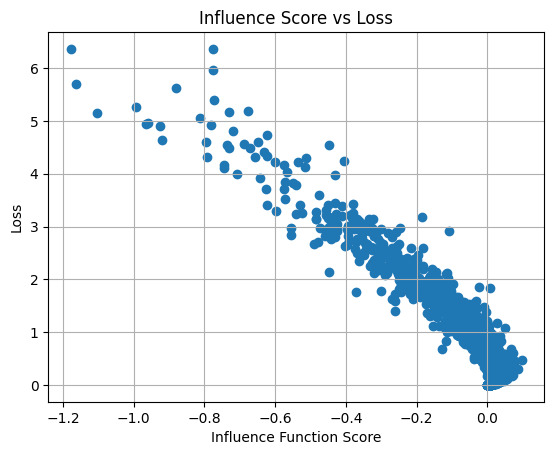

In [41]:
import matplotlib.pyplot as plt

plt.scatter(df["Score"], df["Loss"])
plt.xlabel("Influence Function Score")
plt.ylabel("Loss")
plt.title("Influence Score vs Loss")
plt.grid(True)
plt.show()

5. Then, the regression line for the two data are fit here

In [42]:
X = df["Score"].values.reshape(-1, 1)
y = df["Loss"].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: -6.592603006134981
Intercept: 0.21486949291936078
R^2: 0.7953833334319693


6. We finally plot the regression line inside the original plot.

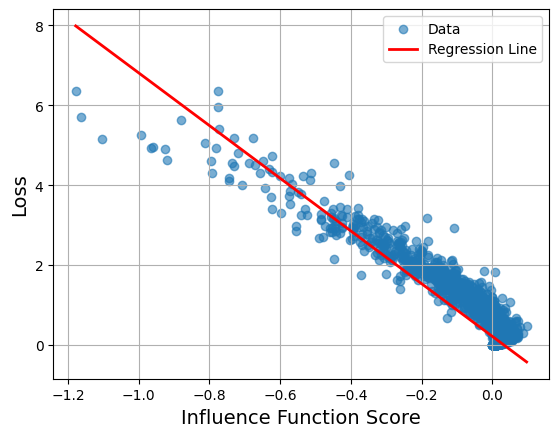

In [43]:
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, y_pred, linewidth=2, label="Regression Line",color="red")

plt.xlabel("Influence Function Score", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

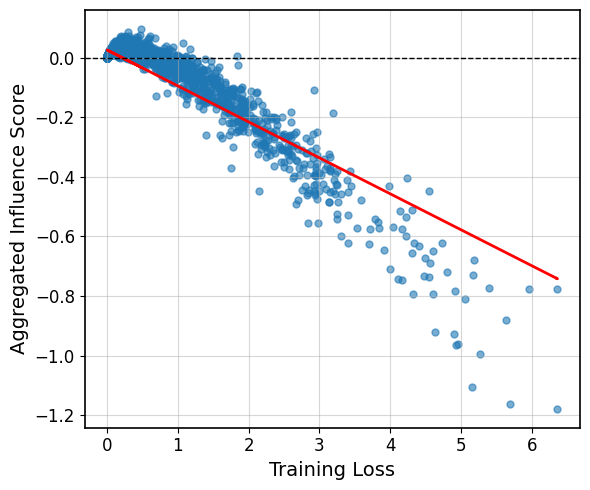

In [44]:
x_loss = y.reshape(-1, 1)          # x-axis: Training loss
y_infl = X.reshape(-1, 1)          # y-axis: Aggregated influence score

reg = LinearRegression()
reg.fit(x_loss, y_infl)
y_pred = reg.predict(x_loss)

plt.figure(figsize=(6, 5))

plt.scatter(x_loss, y_infl, alpha=0.6, s=25)
plt.plot(x_loss, y_pred, linewidth=2, color="red")

# horizontal zero line
plt.axhline(y=0, color="black", linewidth=1, linestyle="--")

# labels with larger font
plt.xlabel("Training Loss", fontsize=14)
plt.ylabel("Aggregated Influence Score", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# grid
plt.grid(True, alpha=0.5)

# add border / box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# remove title and legend
# plt.title(...)
# plt.legend()

plt.savefig(
    "Outliers_Synthetic_IF.png",
    dpi=600,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()

7. Same procedure happens in the following for the TracIn score and Loss.

In [45]:
df_TCLOSS = pd.merge(df_TC, df_loss, on="Train_ID", how="inner")
print(df_TCLOSS)

      Train_ID     Score      Loss
0         3957  0.000940  1.434381
1          715  0.000937  2.082366
2         7782  0.000900  1.841699
3         2372  0.000898  1.108120
4         5017  0.000873  1.356651
...        ...       ...       ...
9995      9743 -0.003451  4.409663
9996      2730 -0.003507  4.736581
9997      6972 -0.003578  6.363977
9998      6845 -0.003592  5.963240
9999      7194 -0.003753  5.630051

[10000 rows x 3 columns]


In [46]:
scores = df_TCLOSS["Score"]

print("=== Basic Statistics ===")
print(f"Mean: {np.mean(scores):.6f}")
print(f"Median: {np.median(scores):.6f}")
print(f"Std: {np.std(scores):.6f}")
print(f"Min: {np.min(scores):.6f}")
print(f"Max: {np.max(scores):.6f}")

=== Basic Statistics ===
Mean: -0.000000
Median: -0.000000
Std: 0.000311
Min: -0.003753
Max: 0.000940


In [47]:
total = len(scores)

num_positive = np.sum(scores > 0)
num_negative = np.sum(scores < 0)

print("\n=== Sign Distribution ===")
print(f"Positive: {num_positive} ({num_positive/total*100:.2f}%)")
print(f"Negative: {num_negative} ({num_negative/total*100:.2f}%)")


=== Sign Distribution ===
Positive: 4975 (49.75%)
Negative: 5025 (50.25%)


In [48]:
neg = scores[scores < 0]
pos = scores[scores > 0]

print("Mean |neg|:", np.mean(np.abs(neg)))
print("Mean |pos|:", np.mean(np.abs(pos)))

Mean |neg|: 0.00012960008241691393
Mean |pos|: 0.00012996916597067052


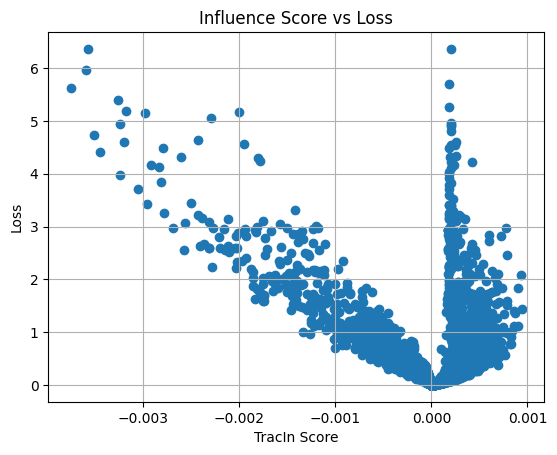

In [49]:
import matplotlib.pyplot as plt

plt.scatter(df_TCLOSS["Score"], df_TCLOSS["Loss"])
plt.xlabel("TracIn Score")
plt.ylabel("Loss")
plt.title("Influence Score vs Loss")
plt.grid(True)
plt.show()

In [50]:
from sklearn.linear_model import LinearRegression
import numpy as np
X = df_TCLOSS["Score"].values.reshape(-1, 1)
y = df_TCLOSS["Loss"].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: -757.5847743234589
Intercept: 0.21613789829337582
R^2: 0.1853781985681897


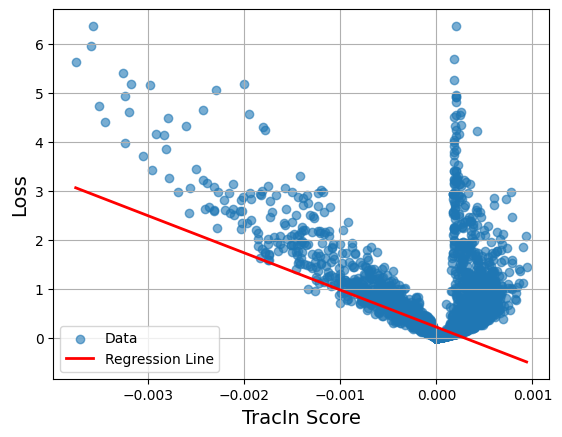

In [51]:
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, y_pred, linewidth=2, label="Regression Line",color="red")

plt.xlabel("TracIn Score", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

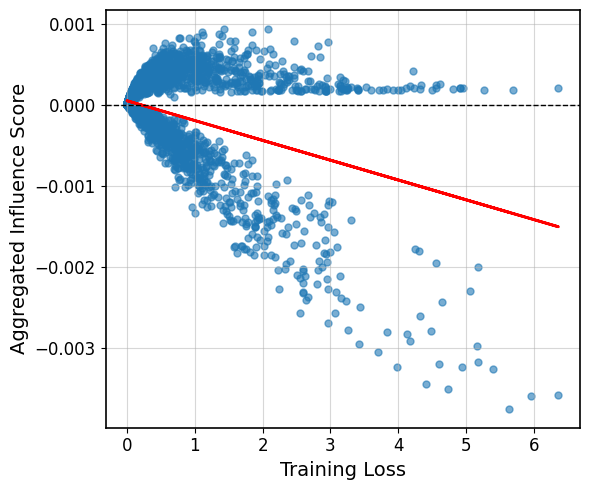

In [52]:
x_loss = y.reshape(-1, 1)          # x-axis: Training loss
y_infl = X.reshape(-1, 1)          # y-axis: Aggregated influence score

reg = LinearRegression()
reg.fit(x_loss, y_infl)
y_pred = reg.predict(x_loss)

plt.figure(figsize=(6, 5))

plt.scatter(x_loss, y_infl, alpha=0.6, s=25)
plt.plot(x_loss, y_pred, linewidth=2, color="red")

# horizontal zero line
plt.axhline(y=0, color="black", linewidth=1, linestyle="--")

# labels with larger font
plt.xlabel("Training Loss", fontsize=14)
plt.ylabel("Aggregated Influence Score", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# grid
plt.grid(True, alpha=0.5)

# add border / box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# remove title and legend
# plt.title(...)
# plt.legend()

plt.savefig(
    "Outliers_Synthetic_TC.png",
    dpi=600,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()